In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as plt

# Modling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [3]:
df = pd.read_csv(r'D:\MLproject\Notebook\data\StudentsPerformance.csv')

In [4]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [6]:
X = df.drop(columns=['math score'],axis=1)
y = df['math score']

In [9]:
num_feature = X.select_dtypes(exclude="object").columns
cat_feature = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transform = StandardScaler()
oh_transform = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transform,cat_feature),
        ("StandardScaler", numeric_transform,num_feature)
    ]
)

In [10]:
X = preprocessor.fit_transform(X)   

In [11]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=40)

In [12]:
def evalute_model(true, predict):
    mae = mean_absolute_error(true, predict)
    mse = mean_squared_error(true, predict)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, predict)

    return mae,mse,rmse,r2

In [16]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbor Reg": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "XGB Regressor": XGBRegressor(),
    "CatBoost Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    model_train_mae, model_train_mse, model_train_rmse, model_train_r2 = evalute_model(y_train, y_train_pred)  
    model_test_mae, model_test_mse, model_test_rmse, model_test_r2 = evalute_model(y_test, y_test_pred)  

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model performace for training set")
    print(f"rmse: {model_train_rmse}")
    print(f"mse: {model_train_mse}")
    print(f"mae: {model_train_mae}")
    print(f"r2: {model_train_r2}")

    print("---------------------------------------------")

    print("Model performace for testing set")
    print(f"rmse: {model_test_rmse}")
    print(f"mse: {model_test_mse}")
    print(f"mae: {model_test_mae}")
    print(f"r2: {model_test_r2}")
    r2_list.append(model_test_r2)


Linear Regression
Model performace for training set
rmse: 5.238292004556447
mse: 27.439703125
mae: 4.180083333333333
r2: 0.8814788108442517
---------------------------------------------
Model performace for testing set
rmse: 5.6201795317187155
mse: 31.58641796875
mae: 4.494125
r2: 0.8591099281610646
Lasso
Model performace for training set
rmse: 6.485871274619614
mse: 42.066526190935846
mae: 5.086376841861895
r2: 0.8183007051829703
---------------------------------------------
Model performace for testing set
rmse: 6.816855555101471
mse: 46.469519659117786
mae: 5.492325105387329
r2: 0.792724392820633
Ridge
Model performace for training set
rmse: 5.230819874305015
mse: 27.36147655742434
mae: 4.162251460331772
r2: 0.8818166973647583
---------------------------------------------
Model performace for testing set
rmse: 5.641272267505371
mse: 31.823952796125187
mae: 4.527263790930781
r2: 0.8580504126779779
K-Neighbor Reg
Model performace for training set
rmse: 5.930297350611238
mse: 35.168426

In [17]:
pd.DataFrame(list(zip(model_list,r2_list)), columns=['Model_name', 'R2_score']).sort_values(by=["R2_score"],ascending=False)

,Model_name,R2_score
0,Linear Regression,0.859110
2,Ridge,0.858050
7,CatBoost Regressor,0.835158
5,Random Forest,0.824618
3,K-Neighbor Reg,0.810385
8,AdaBoost Regressor,0.809706
1,Lasso,0.792724
6,XGB Regressor,0.784438
4,Decision Tree,0.689106


Linear Regressor

In [19]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(x_train, y_train)
y_pred = lin_model.predict(x_test)
score = r2_score(y_test, y_pred)
print("Accuracy of model:", score)

Accuracy of model: 0.8591099281610646


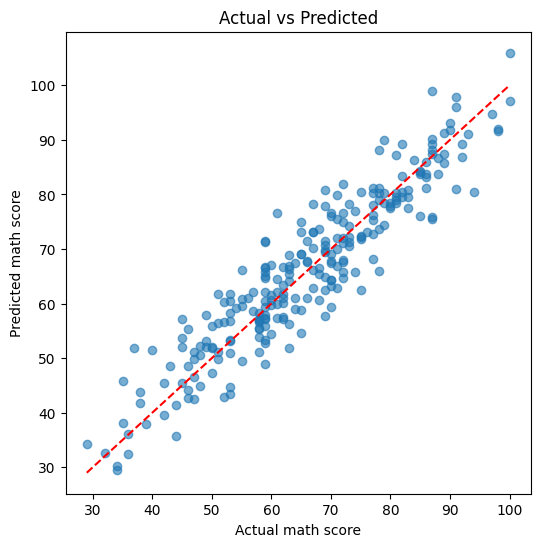

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test.values, y_pred, alpha=0.6)
mn, mx = y_test.min(), y_test.max()
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel('Actual math score')
plt.ylabel('Predicted math score')
plt.title('Actual vs Predicted')
plt.show()

Difference between actual and predicted values

In [22]:
pred_df = pd.DataFrame({'Actual value':y_test, 'predicted val':y_pred, 'Difference':y_test-y_pred})

In [23]:
pred_df

,Actual value,predicted val,Difference
204,59,48.84375,10.15625
71,63,64.09375,-1.09375
594,92,86.87500,5.12500
672,69,69.50000,-0.50000
14,50,47.28125,2.71875
...,...,...,...
199,78,66.03125,11.96875
383,38,41.78125,-3.78125
764,60,67.09375,-7.09375
197,55,60.90625,-5.90625
